<a href="https://colab.research.google.com/github/dorcasojo/AVCAD-/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

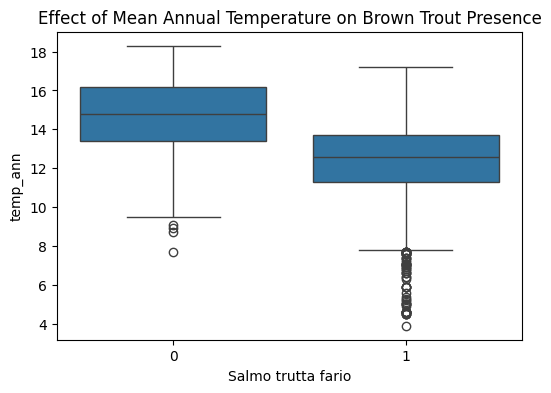

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro
import numpy as np


df = pd.read_csv("/content/EFIplus_medit.csv", sep=';')
print(df.columns.tolist())

# Filter only valid rows
df1 = df[["temp_ann", "Salmo trutta fario"]].dropna()

plt.figure(figsize=(6,4))
sns.boxplot(
    x="Salmo trutta fario",
    y="temp_ann",
    data=df1
)

plt.title("Effect of Mean Annual Temperature on Brown Trout Presence")
plt.show()

Compare effect in Minho vs Tagus (effect sizes)

In [ ]:
df2 = df[df["Catchment_name"].isin(["Minho", "Tagus"])][
    ["Catchment_name", "temp_ann", "Salmo trutta fario"]
].dropna()

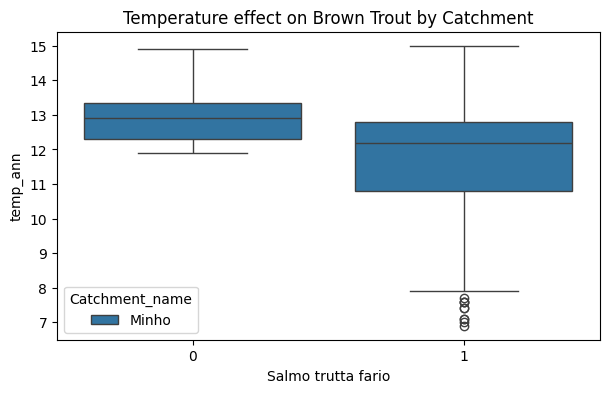

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x="Salmo trutta fario",
    y="temp_ann",
    hue="Catchment_name",
    data=df2
)

plt.title("Temperature effect on Brown Trout by Catchment")
plt.show()

In [ ]:
effect_sizes = df2.groupby(["Catchment_name", "Salmo trutta fario"])["temp_ann"].mean().unstack()

effect_sizes["effect_size"] = effect_sizes[1] - effect_sizes[0]
print(effect_sizes)

Salmo trutta fario          0          1  effect_size
Catchment_name                                       
Minho               12.963636  11.840948    -1.122688


 Interpretation of the map above; Larger difference = stronger temperature influence
Compare Minho vs Tagus:
stronger ecological constraint in colder basin usually = Minho

**Test if actual_river_slope is normally distributed**

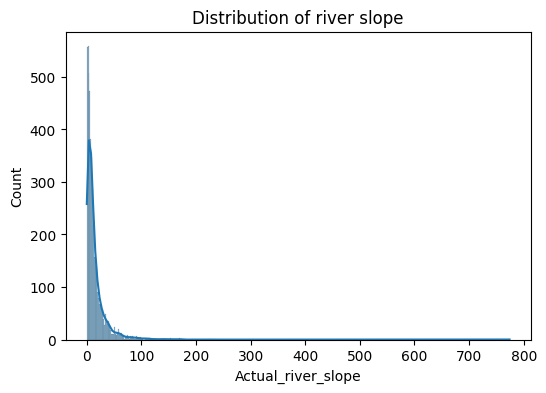

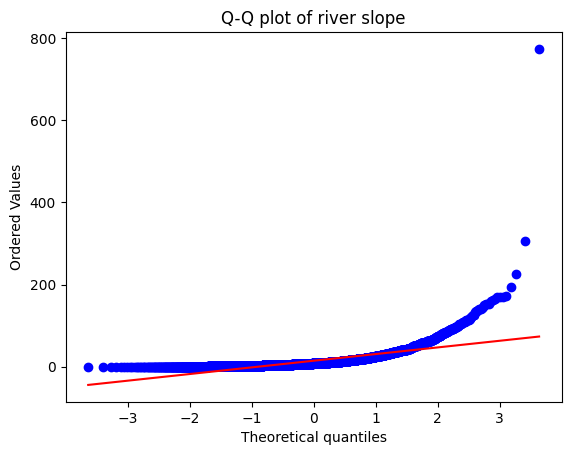

In [ ]:
slope = df["Actual_river_slope"].dropna()

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(slope, kde=True)
plt.title("Distribution of river slope")
plt.show()

# Q-Q plot
stats.probplot(slope, dist="norm", plot=plt)
plt.title("Q-Q plot of river slope")
plt.show()


In [ ]:

from scipy.stats import shapiro

stat, p = shapiro(slope.sample(500, random_state=1))  # sample if dataset is large

print("Shapiro-Wilk p-value:", p)

Shapiro-Wilk p-value: 4.5216697709711103e-29


**Bootstrap sampling of river slope mean**

In [ ]:


means = []

for i in range(100):
    sample = slope.sample(n=2000, replace=True)
    means.append(sample.mean())

means = np.array(means)

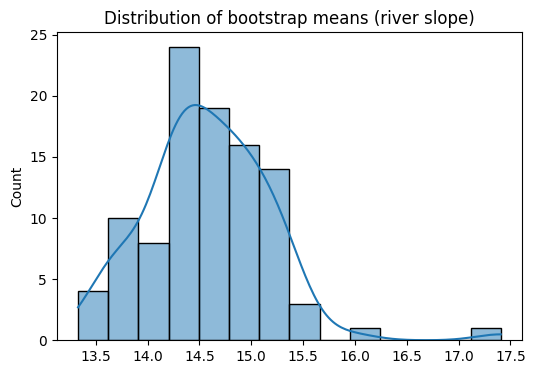

Shapiro-Wilk p-value (means): 0.00031202168345177683


In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(means, kde=True)
plt.title("Distribution of bootstrap means (river slope)")
plt.show()
stat, p = shapiro(means)

print("Shapiro-Wilk p-value (means):", p)